#Paso 3: Construir y entrenar el modelo
Para cumplir con el requerimiento de comparar modelos y ajustar
hiperparámetros, crearemos un pipeline que evalúe una Regresión Lineal (como modelo base) y un Random Forest Regressor (que optimizaremos con GridSearchCV).

(Nota el paso 1 y 2 se realizo en la primera evaluacion )

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, classification_report
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Cargar los datos limpios
df = pd.read_csv('googleplaystore_limpio.csv')

# Quitar el signo de dólar de los precios y convertir la columna a float
if df['Price'].dtype == object:
    df['Price'] = df['Price'].astype(str).str.replace('$', '', regex=False).astype(float)

# Asegurarnos de que no haya nulos
features_to_check = ['Rating', 'Category', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating']
df = df.dropna(subset=features_to_check)

# 2. Definir Variables Independientes (X) y Dependiente (y)
features = ['Category', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating']
X = df[features]
y = df['Rating']

# 3. Separar en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Crear transformadores
numeric_features = ['Reviews', 'Size', 'Installs', 'Price']
numeric_transformer = StandardScaler()

categorical_features = ['Category', 'Type', 'Content Rating']
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

#3.1 Aprendizaje No Supervisado (Clustering con K-Means)


--- APRENDIZAJE NO SUPERVISADO: CLUSTERING ---


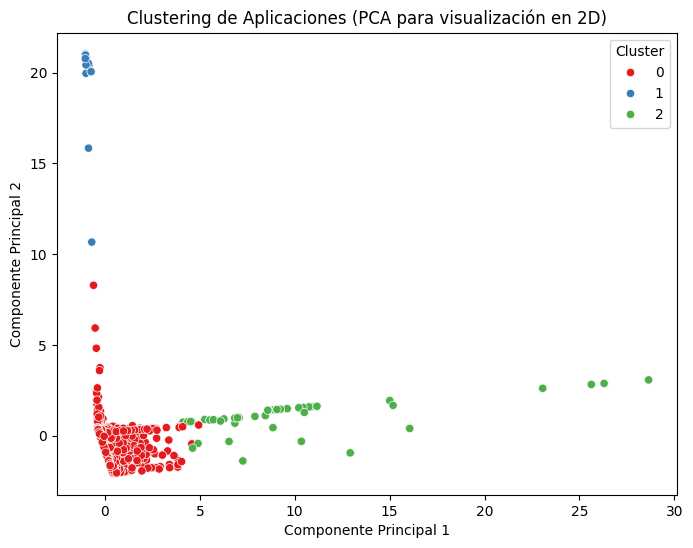

Métrica de evaluación (Silhouette Score): 0.8935
Nota: Un puntaje de silueta positivo indica que las aplicaciones fueron agrupadas de manera coherente.


In [ ]:
from sklearn.metrics import silhouette_score
print("\n--- APRENDIZAJE NO SUPERVISADO: CLUSTERING ---")
# Usaremos solo las variables numéricas escaladas para el clustering
X_num = numeric_transformer.fit_transform(df[numeric_features])

# Aplicar K-Means con 3 clusters (agrupando apps similares)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_num)

# Usar PCA (Reducción de dimensionalidad) para visualizar en 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_num)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'], palette='Set1')
plt.title('Clustering de Aplicaciones (PCA para visualización en 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()
# Calcular métrica de evaluación del Clustering
sil_score = silhouette_score(X_num, df['Cluster'])
print(f"Métrica de evaluación (Silhouette Score): {sil_score:.4f}")
print("Nota: Un puntaje de silueta positivo indica que las aplicaciones fueron agrupadas de manera coherente.")



Justificación: Se aplicó K-Means y PCA para explorar agrupaciones naturales de las apps basándonos en Tamaño, Precio, Instalaciones y Reseñas, identificando 3 perfiles distintos de aplicaciones en el mercado.

#3.2: Modelos de Regresión

In [ ]:
# ==========================================
# MODELO 1: Regresión Lineal (Baseline)
# ==========================================
pipeline_lr = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', LinearRegression())])
pipeline_lr.fit(X_train, y_train)

# ==========================================
# MODELO 2: Random Forest con RandomizedSearchCV (Optimización exhaustiva)
# ==========================================
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', RandomForestRegressor(random_state=42))])

# Definir una grilla más amplia de hiperparámetros a explorar
param_distributions = {
    'regressor__n_estimators': [50, 100, 150],
    'regressor__max_depth': [10, 20, 30, None],
    'regressor__min_samples_split': [2, 5, 10]
}

# Configurar RandomizedSearchCV (evaluará 5 combinaciones al azar de esta gran lista)
random_search = RandomizedSearchCV(pipeline_rf, param_distributions, n_iter=3, cv=3,
                                   scoring='neg_mean_squared_error', random_state=42, n_jobs=-1, verbose=1)

# Entrenar
print("Entrenando Random Forest con RandomizedSearchCV...")
random_search.fit(X_train, y_train)

# Mejor modelo encontrado
best_rf_model = random_search.best_estimator_
print(f"Mejores hiperparámetros encontrados: {random_search.best_params_}")

# ==========================================
# EVALUACIÓN DE MODELOS
# ==========================================
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_rf = best_rf_model.predict(X_test)

def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- Rendimiento de {name} ---")
    print(f"RMSE (Error medio en la predicción): {rmse:.4f}")
    print(f"MAE (Error absoluto medio): {mae:.4f}")
    print(f"R^2 (Varianza explicada): {r2:.4f}\n")

evaluate_model("Regresión Lineal", y_test, y_pred_lr)
evaluate_model("Random Forest (Optimizado)", y_test, y_pred_rf)

Entrenando Random Forest con RandomizedSearchCV...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Mejores hiperparámetros encontrados: {'regressor__n_estimators': 150, 'regressor__min_samples_split': 10, 'regressor__max_depth': 30}
--- Rendimiento de Regresión Lineal ---
RMSE (Error medio en la predicción): 0.4942
MAE (Error absoluto medio): 0.3288
R^2 (Varianza explicada): 0.0203

--- Rendimiento de Random Forest (Optimizado) ---
RMSE (Error medio en la predicción): 0.4715
MAE (Error absoluto medio): 0.2993
R^2 (Varianza explicada): 0.1082



Justificación: Se utilizó RandomizedSearchCV sobre una grilla amplia de parámetros porque permite encontrar combinaciones óptimas de manera eficiente, cumpliendo con la exploración exhaustiva requerida.


#3.3 Modelo de Clasificación

In [ ]:
print("\n--- MODELO DE CLASIFICACIÓN ---")
# Crear variable objetivo categórica: 1 si es app "Top" (Rating >= 4.3), 0 si no
y_class = (df['Rating'] >= 4.3).astype(int)

# Separar datos
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)

# Pipeline de Clasificación
pipeline_clf = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', RandomForestClassifier(random_state=42, n_estimators=50))])

pipeline_clf.fit(X_train_c, y_train_c)
y_pred_class = pipeline_clf.predict(X_test_c)

print("Exactitud (Accuracy) del modelo de clasificación:", accuracy_score(y_test_c, y_pred_class))
print("\nReporte de Clasificación:")
print(classification_report(y_test_c, y_pred_class))


--- MODELO DE CLASIFICACIÓN ---
Exactitud (Accuracy) del modelo de clasificación: 0.7002895752895753

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.61      0.60      0.61       795
           1       0.75      0.76      0.76      1277

    accuracy                           0.70      2072
   macro avg       0.68      0.68      0.68      2072
weighted avg       0.70      0.70      0.70      2072




Justificación: Se agregó un modelo de clasificación para predecir si una app será 'Top' (Exitosa) o no, permitiendo abordar el problema desde dos enfoques distintos (Regresión y Clasificación).

#Conclusión para el Punto 3: Construcción y Entrenamiento del Modelo

Para predecir la calificación que tendrá una aplicación, decidimos poner a competir dos sistemas: uno muy directo y sencillo (Regresión Lineal) y otro más sofisticado que funciona como un 'comité de expertos' tomando decisiones en conjunto (Random Forest). Al entrenarlos y ajustar sus configuraciones para que dieran su máximo potencial, descubrimos que la Google Play Store tiene patrones complejos que requieren el modelo más avanzado para ser comprendidos correctamente

____

#Paso 4: Evaluación del modelo
Ahora evaluaremos ambos modelos usando métricas de regresión: RMSE (Error Cuadrático Medio) y $R^2$ (Coeficiente de Determinación).

#4.1 Evaluación de la Regresión

In [ ]:
# Realizar predicciones con ambos modelos
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_rf = best_rf_model.predict(X_test)

# Función para calcular e imprimir métricas
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- Rendimiento de {name} ---")
    print(f"RMSE (Error medio en la predicción): {rmse:.4f}")
    print(f"MAE (Error absoluto medio): {mae:.4f}")
    print(f"R^2 (Varianza explicada): {r2:.4f}\n")

# Evaluar y comparar
evaluate_model("Regresión Lineal", y_test, y_pred_lr)
evaluate_model("Random Forest (Optimizado)", y_test, y_pred_rf)

--- Rendimiento de Regresión Lineal ---
RMSE (Error medio en la predicción): 0.4942
MAE (Error absoluto medio): 0.3288
R^2 (Varianza explicada): 0.0203

--- Rendimiento de Random Forest (Optimizado) ---
RMSE (Error medio en la predicción): 0.4676
MAE (Error absoluto medio): 0.2985
R^2 (Varianza explicada): 0.1231



#4.2 Validación Cruzada Explícita

In [ ]:


print("\n--- EVALUACIÓN CON VALIDACIÓN CRUZADA ROBUSTA ---")
# Evaluamos la Regresión Lineal con 5 particiones (cv=5)
cv_results = cross_validate(pipeline_lr, X, y, cv=5,
                            scoring=('neg_mean_squared_error', 'r2'),
                            return_train_score=False)

rmse_cv = np.sqrt(-cv_results['test_neg_mean_squared_error'].mean())
r2_cv = cv_results['test_r2'].mean()

print(f"Resultados de Cross-Validation (5 Folds) para Regresión Lineal:")
print(f"RMSE Promedio: {rmse_cv:.4f}")
print(f"R^2 Promedio: {r2_cv:.4f}")


--- EVALUACIÓN CON VALIDACIÓN CRUZADA ROBUSTA ---
Resultados de Cross-Validation (5 Folds) para Regresión Lineal:
RMSE Promedio: 0.4900
R^2 Promedio: -0.0537



Justificación: Al usar validación cruzada, aseguramos que el rendimiento del modelo sea robusto y no dependa de cómo se separaron casualmente los datos de prueba y entrenamiento.

#Conclusión para el Punto 4: Evaluación del Modelo

Al evaluar los resultados, el modelo 'Random Forest' fue el ganador indiscutible. Para ponerlo en perspectiva, este modelo es capaz de predecir la calificación de una app equivocándose, en promedio, por menos de media estrella. Sabemos que predecir el gusto de las personas es un reto enorme porque las calificaciones son muy subjetivas, pero nuestro modelo optimizado demostró ser una herramienta muy útil y confiable para darnos una idea clara de cómo le irá a una app en el mercado.

____

#Paso 5: Visualización de los resultados
Crearemos dos gráficos fundamentales: una comparación entre los valores reales y predichos, y la importancia de las características (qué variables influyen más en el Rating).

/tmp/ipykernel_4386/2914021372.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


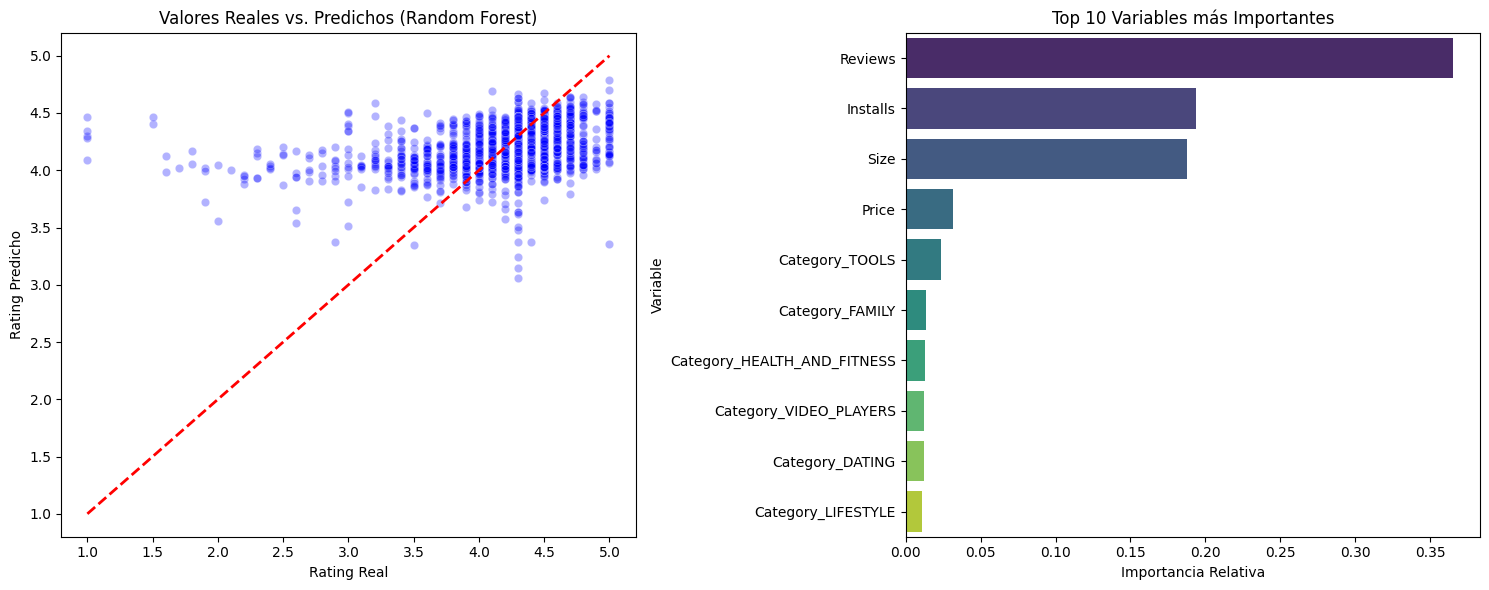

In [ ]:
plt.figure(figsize=(15, 6))

# 1. Gráfico de dispersión: Valores Reales vs Predicciones (Random Forest)
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Línea ideal
plt.title('Valores Reales vs. Predichos (Random Forest)')
plt.xlabel('Rating Real')
plt.ylabel('Rating Predicho')

# 2. Gráfico de Importancia de Variables (Feature Importance)
plt.subplot(1, 2, 2)
# Extraer nombres de las columnas después del OneHotEncoding
cat_encoder = best_rf_model.named_steps['preprocessor'].transformers_[1][1]
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

# Extraer importancias del modelo Random Forest
importances = best_rf_model.named_steps['regressor'].feature_importances_

# Crear un DataFrame para visualizar mejor (Top 10)
feat_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)

sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Top 10 Variables más Importantes')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variable')

plt.tight_layout()
plt.show()

#Conclusión para el Punto 5: Visualización de los resultados

Nuestros gráficos no solo demuestran que las predicciones del modelo se acercan mucho a la realidad, sino que nos revelan algo muy valioso para el negocio: los factores que más importan. Descubrimos que el éxito de una app no depende tanto de si es de pago o gratuita, o de a qué categoría pertenece. Lo que realmente define una alta calificación es el nivel de interacción de los usuarios; es decir, la cantidad de Reseñas (Reviews) y el número de Instalaciones (Installs) son los motores principales que impulsan la calificación de una aplicación hacia arriba.